# Whole-genome doubling and the allele layer

A normal genome is **1 + 1** (one copy per parent). A **whole-genome duplication (WGD)** doubles it to
**2 + 2** — and roughly a third of human tumours (PCAWG) carry one. WGD is treacherous for copy-number
callers: a *pure* doubling is perfectly **balanced** (both homologs at 2), so **total copy number and
B-allele frequency look exactly diploid**. Only when the doubling is followed by a **loss** does an
allelically **imbalanced, even-total** state appear — e.g. **4 + 0** or **3 + 1** — that total CN alone
cannot tell from a balanced 2 + 2.

This notebook uses iscc's ground truth (which cells are WGD, and the **per-homolog** copy number) to
show (1) the ploidy signature of WGD, (2) why total CN misses it, and (3) that WGD **manufactures the
allele-only-detectable states** the allele layer (`cell_rna_baf`) can see. The microenvironment is the
**balanced-BAF anchor**: normal cells stay at 1 + 1, BAF ≈ 0.5.

> The allele-aware caller that exploits this — **Numbat** — is benchmarked in
> `validation/validate_numbat.py --wgd-rate`.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B


def segment_allele_cn(t):
    '''cell_id -> (n_seg, 2) per-homolog copy number (p, m); None if the genotype has no genome.
    cell_cnv is TOTAL CN only (a 4+0 reads as total 4, identical to a balanced 2+2); these per-homolog
    counts carry the allelic imbalance a 4+0 / 3+1 state has that a total-CN view cannot see.'''
    gid = t.cell_data["cell_type"].iloc[:, 0].astype(str).values
    idx = np.asarray(t.cell_data["cell_type"].index)
    g = t.genotypes; cache = {}; out = {}
    for cell, gg in zip(idx, gid):
        if gg not in cache:
            rep = g.get(gg)
            cache[gg] = (np.array([(len(s["p"]), len(s["m"])) for s in rep.genome], dtype=int)
                         if rep is not None and hasattr(rep, "genome") else None)
        out[cell] = cache[gg]
    return out

## 1. Grow a WGD tumour and assemble the mixture

The shared substrate already has WGD on (`wgd_rate=0.05`) and the allele-resolved expression layer on
(so `cell_rna_baf` exists). We grow it and assemble a realistic-purity mixture of malignant +
microenvironment.

In [2]:
t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer = types == "cancer"
is_wgd = cd["cell_wgd"]["is_wgd"].values
print("allele + WGD layers present:",
      [k for k in cd if k in ("cell_wgd", "cell_rna_baf", "cell_exp_p", "cell_exp_m")])
print(f"grown section: {len(types):,} cells | malignant {is_cancer.sum():,} "
      f"normal {(~is_cancer).sum():,} | purity {is_cancer.mean():.1%}")
print(f"WGD: {is_wgd.sum():,} cells total | {is_wgd[is_cancer].mean():.0%} of malignant cells are WGD")

rng = np.random.default_rng(0)
cancer_cells = list(rng.choice(idx[is_cancer], size=500, replace=False))
normal_cells = list(rng.choice(idx[np.isin(types, ("epithelial", "stromal"))], size=350, replace=False))
mixture = cancer_cells + normal_cells
pos = {c: i for i, c in enumerate(idx)}
mix_pos = np.array([pos[c] for c in mixture])
print(f"assayed mixture: {len(mixture)} cells | purity {len(cancer_cells)/len(mixture):.0%}")

allele + WGD layers present: ['cell_wgd', 'cell_exp_p', 'cell_exp_m', 'cell_rna_baf']
grown section: 32,454 cells | malignant 11,190 normal 21,264 | purity 34.5%
WGD: 3,592 cells total | 32% of malignant cells are WGD
assayed mixture: 850 cells | purity 59%


## 2. Where the WGD subclones sit

WGD is a clonal event: whole subclones inherit the doubled genome. Left: coloured by the true `is_wgd`
flag over the multi-focal ductal field (gland walls drawn), the doubled cells form **coherent patches**
within the foci, while the microenvironment is uniformly non-WGD. Right: the malignant cells by
`cell_gland` — the WGD patches sit inside the foci a single founder colonised.

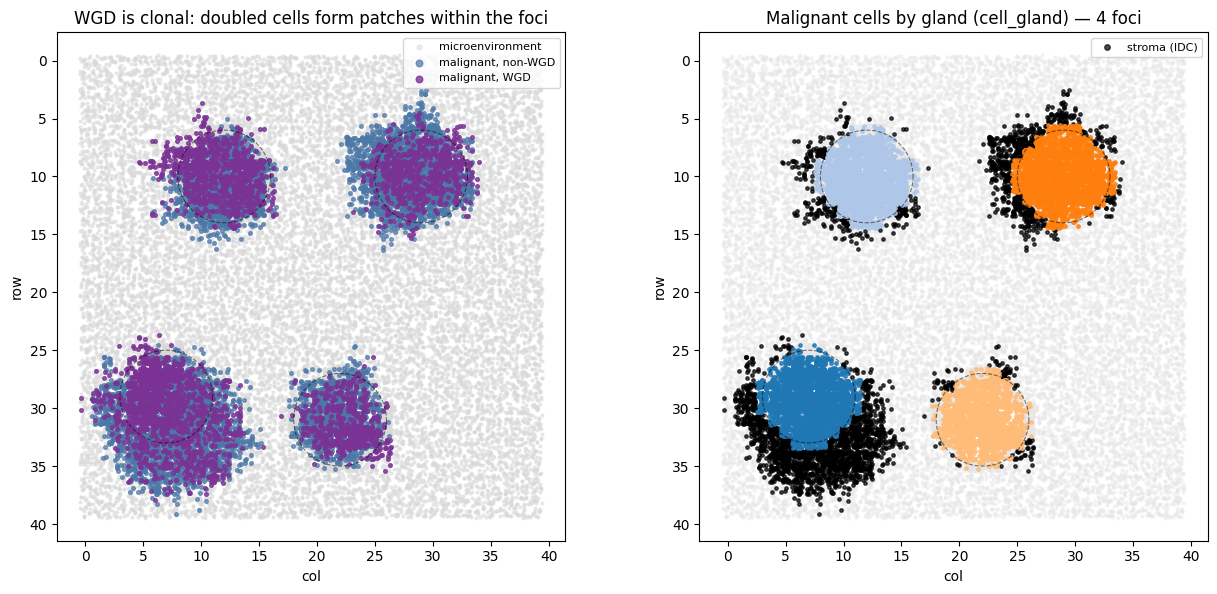

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))
gland = B.cell_gland(t)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].scatter(jx[~is_cancer], jy[~is_cancer], s=4, c="0.85", alpha=0.5, label="microenvironment")
axes[0].scatter(jx[is_cancer & ~is_wgd], jy[is_cancer & ~is_wgd], s=7, c="#4c78a8", alpha=0.7,
                label="malignant, non-WGD")
axes[0].scatter(jx[is_cancer & is_wgd], jy[is_cancer & is_wgd], s=7, c="#7b3294", alpha=0.8,
                label="malignant, WGD")
B.draw_glands(axes[0], t)
axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].legend(fontsize=8, markerscale=1.8, loc="upper right")
axes[0].set_title("WGD is clonal: doubled cells form patches within the foci")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

cmap = plt.get_cmap("tab20")
gvals = gland[is_cancer]
axes[1].scatter(jx[~is_cancer], jy[~is_cancer], s=4, c="0.9", alpha=0.4)
axes[1].scatter(jx[is_cancer][gvals == -1], jy[is_cancer][gvals == -1], s=6, c="k", alpha=0.7,
                label="stroma (IDC)")
for g in sorted(set(gvals[gvals >= 0])):
    m = gvals == g
    axes[1].scatter(jx[is_cancer][m], jy[is_cancer][m], s=6, color=cmap(int(g) % 20), alpha=0.8)
B.draw_glands(axes[1], t)
axes[1].set_aspect("equal"); axes[1].invert_yaxis()
axes[1].legend(fontsize=8, markerscale=1.6, loc="upper right")
axes[1].set_title(f"Malignant cells by gland (cell_gland) — {len(B.glands_colonised(t))} foci")
axes[1].set_xlabel("col"); axes[1].set_ylabel("row")
plt.tight_layout()

## 3. The ploidy signature of WGD

Average copy number per cell (mean total CN over the genome) is the classic ploidy readout. The
microenvironment anchors a sharp peak at **2**; malignant non-WGD cells sit near it (with CNA spread);
the WGD malignant cells form a **second mode near 4** — doubled, minus whatever they have since lost.

mean ploidy — normal 2.00 | malig non-WGD 1.99 | malig WGD 4.00


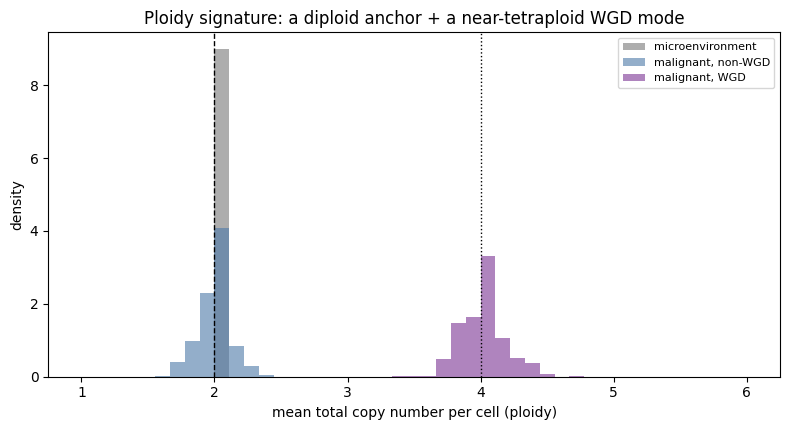

In [4]:
mean_cn = cd["cell_cnv"].values.mean(1)
fig, ax = plt.subplots(figsize=(8, 4.4))
bins = np.linspace(1, 6, 46)
ax.hist(mean_cn[~is_cancer], bins=bins, color="0.6", alpha=0.8, density=True, label="microenvironment")
ax.hist(mean_cn[is_cancer & ~is_wgd], bins=bins, color="#4c78a8", alpha=0.6, density=True,
        label="malignant, non-WGD")
ax.hist(mean_cn[is_cancer & is_wgd], bins=bins, color="#7b3294", alpha=0.6, density=True,
        label="malignant, WGD")
ax.axvline(2, color="k", ls="--", lw=1); ax.axvline(4, color="k", ls=":", lw=1)
ax.set_xlabel("mean total copy number per cell (ploidy)"); ax.set_ylabel("density")
ax.set_title("Ploidy signature: a diploid anchor + a near-tetraploid WGD mode")
ax.legend(fontsize=8)
plt.tight_layout()
print(f"mean ploidy — normal {mean_cn[~is_cancer].mean():.2f} | "
      f"malig non-WGD {mean_cn[is_cancer & ~is_wgd].mean():.2f} | "
      f"malig WGD {mean_cn[is_cancer & is_wgd].mean():.2f}")

## 4. Why total copy number alone misses WGD

Here is the crux. A **pure** doubling takes every segment 1 + 1 → 2 + 2: the *total* is 4 everywhere,
but the ratio between homologs is unchanged, so a purely-doubled genome, once re-normalised to its own
median, is **indistinguishable from diploid** on total CN *and* on BAF. The identifiable signal
requires a subsequent **loss** — a doubling *and* loss gives an **imbalanced, even-total** state
(4 + 0, 2 + 0→ but even-total like 4+0) that carries a BAF shift a balanced state does not. The next
cell quantifies exactly those states.

## 5. WGD manufactures allele-only-detectable states (matched WGD-off contrast)

We define a segment as **allele-only detectable** when it is allelically imbalanced (`|p − m| ≥ 1`,
so BAF ≠ 0.5) **and** its total `p + m` is **even** — the copy-neutral-LOH-like states where total copy
number alone is blind but the allele layer is not. Growing a **matched** tumour with `wgd_rate = 0`
(same seed, same everything else) and comparing the fraction of malignant segments in that state
isolates WGD's contribution.

growing the matched WGD-off control (wgd_rate=0) ...


allele-only-detectable fraction  |  WGD off: 0.009   WGD on: 0.031


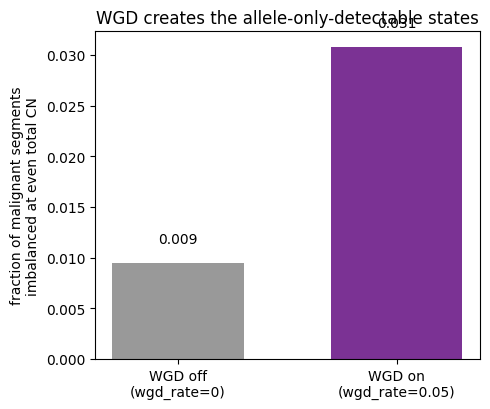

In [5]:
def allele_only_detectable_frac(tt):
    '''fraction of malignant segments that are imbalanced (|p-m|>=1) at EVEN total CN.'''
    ac = segment_allele_cn(tt)
    ty = B.cell_types(tt)
    ids = np.asarray(tt.cell_data["cell_type"].index)[ty == "cancer"]
    tot = imb = 0
    for c in ids:
        a = ac[c]
        if a is None:
            continue
        p, m = a[:, 0], a[:, 1]; total = p + m
        even = (total % 2 == 0) & (total > 0)
        tot += int(even.sum()); imb += int(((np.abs(p - m) >= 1) & even).sum())
    return imb / max(tot, 1)

on_frac = allele_only_detectable_frac(t)
print("growing the matched WGD-off control (wgd_rate=0) ...")
t_off = B.grow_base_tumor(cancer_params={"wgd_rate": 0.0})
off_frac = allele_only_detectable_frac(t_off)
print(f"allele-only-detectable fraction  |  WGD off: {off_frac:.3f}   WGD on: {on_frac:.3f}")

fig, ax = plt.subplots(figsize=(5, 4.2))
ax.bar([0, 1], [off_frac, on_frac], color=["0.6", "#7b3294"], width=0.6)
for i, v in enumerate([off_frac, on_frac]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)
ax.set_xticks([0, 1]); ax.set_xticklabels(["WGD off\n(wgd_rate=0)", "WGD on\n(wgd_rate=0.05)"])
ax.set_ylabel("fraction of malignant segments\nimbalanced at even total CN")
ax.set_title("WGD creates the allele-only-detectable states")
plt.tight_layout()

## 6. The emergent allele signal (BAF)

Because expression is emitted **per homolog**, `cell_rna_baf` carries the allelic imbalance directly —
nothing puts it there by hand. `|BAF − 0.5|` is near zero for balanced segments and for the whole
microenvironment (the 1 + 1 anchor), and rises on the malignant **imbalanced** segments. The imbalance
is **positional** — it tracks the copy-number segments, malignant vs normal.

|BAF-0.5|  malignant imbalanced: 0.303 | malignant balanced: 0.006 | normal anchor: 0.000


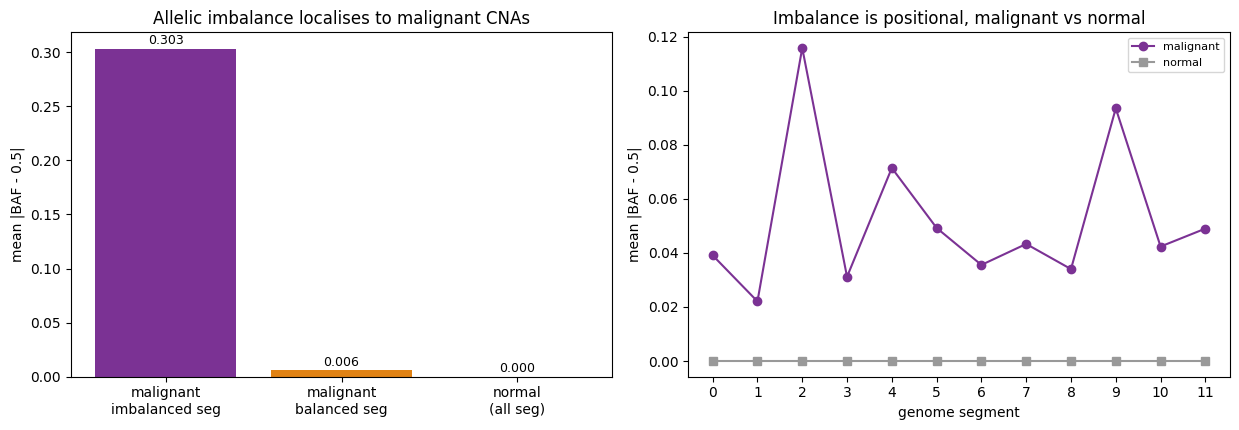

In [6]:
_, gseg = B.segment_cn(t)                      # per-gene -> segment map
baf = np.abs(cd["cell_rna_baf"].values - 0.5)
ac = segment_allele_cn(t)

imb_mal, bal_mal, normal_vals = [], [], []
per_seg_mal = np.zeros(t.n_segments); per_seg_mal_n = np.zeros(t.n_segments)
per_seg_norm = np.zeros(t.n_segments); per_seg_norm_n = np.zeros(t.n_segments)
for i in mix_pos:
    c = idx[i]; row = baf[i]
    if not is_cancer[i]:
        normal_vals.extend(row.tolist())
        for s in range(t.n_segments):
            per_seg_norm[s] += row[gseg == s].sum(); per_seg_norm_n[s] += (gseg == s).sum()
        continue
    a = ac[c]
    if a is None:
        continue
    imb_seg = (np.abs(a[:, 0] - a[:, 1]) >= 1)
    gene_imb = imb_seg[gseg]
    imb_mal.extend(row[gene_imb].tolist()); bal_mal.extend(row[~gene_imb].tolist())
    for s in range(t.n_segments):
        per_seg_mal[s] += row[gseg == s].sum(); per_seg_mal_n[s] += (gseg == s).sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
groups = ["malignant\nimbalanced seg", "malignant\nbalanced seg", "normal\n(all seg)"]
means = [np.mean(imb_mal), np.mean(bal_mal), np.mean(normal_vals)]
axes[0].bar(groups, means, color=["#7b3294", "#e08214", "0.6"])
axes[0].set_ylabel("mean |BAF - 0.5|"); axes[0].set_title("Allelic imbalance localises to malignant CNAs")
for i, v in enumerate(means):
    axes[0].text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
axes[1].plot(range(t.n_segments), per_seg_mal / np.maximum(per_seg_mal_n, 1), "o-",
             color="#7b3294", label="malignant")
axes[1].plot(range(t.n_segments), per_seg_norm / np.maximum(per_seg_norm_n, 1), "s-",
             color="0.6", label="normal")
axes[1].set_xlabel("genome segment"); axes[1].set_ylabel("mean |BAF - 0.5|")
axes[1].set_title("Imbalance is positional, malignant vs normal")
axes[1].legend(fontsize=8); axes[1].set_xticks(range(t.n_segments))
plt.tight_layout()
print(f"|BAF-0.5|  malignant imbalanced: {np.mean(imb_mal):.3f} | "
      f"malignant balanced: {np.mean(bal_mal):.3f} | normal anchor: {np.mean(normal_vals):.3f}")

## What this shows

* **WGD has a ploidy signature** (a near-tetraploid mode over the diploid anchor) and is **clonal +
  spatial** (doubled cells form patches).
* **Total copy number alone cannot identify a pure doubling** — it is balanced. The identifiable trace
  is the **allele-only-detectable** state (imbalanced at even total CN), and a matched `wgd_rate=0`
  control confirms WGD is what **creates** those states.
* The **allele layer sees them**: `cell_rna_baf` deviates from 0.5 exactly on the malignant imbalanced
  segments, with the microenvironment as the balanced anchor — the emergent signal Numbat exploits.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) · [`combining_scdna_scrna`](combining_scdna_scrna.ipynb)
(scDNA + scRNA integration) · [`assay_dna`](assay_dna.ipynb) (the DNA coverage / VAF / ADO model) ·
`validation/validate_numbat.py --wgd-rate` (the allele-aware caller benchmark).